In [2]:
import numpy as np
import matplotlib.pyplot as plt
import measurments
from tqdm import tqdm
import nicegalaxy

In [3]:
sim = measurments.Sim("/u/jbiba/projects/turbulent-driving/astro-turbulence/fiducial")

In [5]:
machs = list()

for i in tqdm(range(len(sim.snaps)), desc=f"Loopin"):
    data = sim.load(i, ["Density", "Masses", "Velocities", "Pressure", "Coordinates"])
    vols = data["Masses"]/data["Density"]
    gamma = 5/3
    soundspeed = np.sqrt(gamma*data["Pressure"]/data["Density"])
    mach_rms = np.sqrt(np.sum(np.sum(data["Velocities"]**2, axis=1)/soundspeed**2 * vols))
    machs.append(mach_rms)

Loopin:   0%|          | 0/298 [00:00<?, ?it/s]

Loopin: 100%|██████████| 298/298 [03:20<00:00,  1.48it/s]


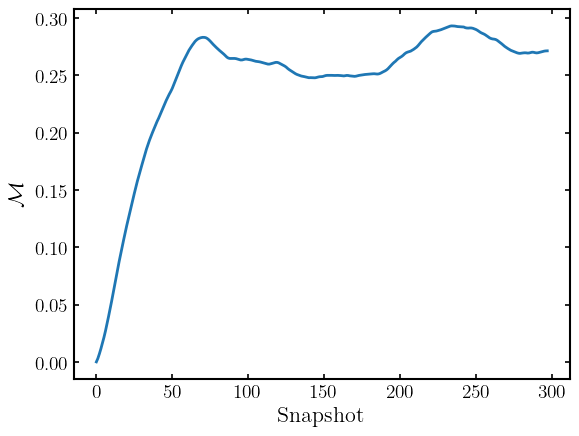

In [7]:
plt.plot(machs)
plt.xlabel("Snapshot")
plt.ylabel(r"$\mathcal{M}$")
plt.savefig("fiducial-machnumber.pdf")

In [5]:
import cmasher as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [6]:
time_bet_snaps = 0.0002855185
time = 978.5 * 290 * time_bet_snaps

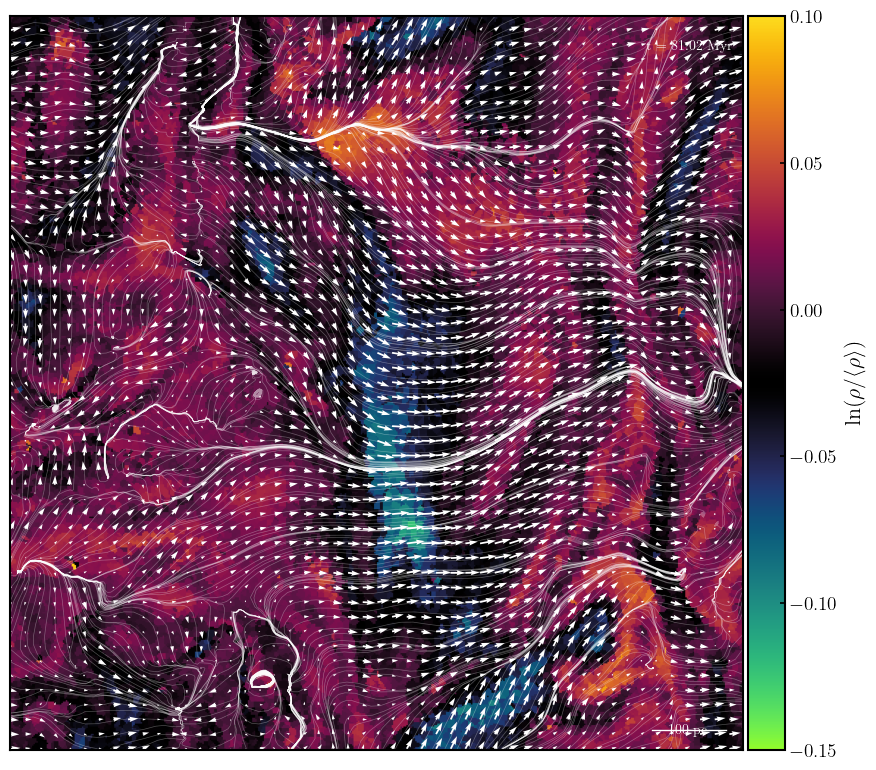

In [11]:
color_names = [
    "seaweed",
    "watermelon",
    "iceburn",
    "redshift",
    "wildfire",
    "guppy",
    "pride",
    "prinsenvlag",
    "holly",
    "waterlily",
    "viola",
    "fusion"
]

snap = 300

coords = sim.load(snap, "Coordinates")
dens = sim.load(snap, "Density")
mfield = sim.load(snap, "MagneticField")

cmaps = {name: getattr(cm, name) for name in color_names}

grid_size = 500
grid = (range(0, grid_size), range(0, grid_size), range(grid_size//2, grid_size//2 + 1))
struct_bulk = nicegalaxy.map_unstructured_to_structured_slice_optimized(coords, mfield, grid_size=grid_size, grid=grid)
Y, X = np.mgrid[0:grid_size, 0:grid_size]
U_bulk = struct_bulk[:, :, 0]
V_bulk = struct_bulk[:, :, 1]
struct_dens = nicegalaxy.map_unstructured_to_structured_slice_optimized(coords, dens,grid_size=grid_size, grid=grid)
fig, ax = plt.subplots(figsize=(10, 10))
ax.invert_yaxis()
cutout_size = 1
scalebar_length = cutout_size/10
scalebar_pixels = scalebar_length/cutout_size * struct_dens.shape[0]
im = ax.imshow(np.log10(struct_dens/np.mean(struct_dens)), cmap=cmaps["wildfire"], interpolation=None, vmin=-0.15, vmax=0.1, origin="lower")
ax.set_yticks([])
ax.set_xticks([])
ax.streamplot(X, Y, U_bulk, V_bulk, density=2, color=(1, 1, 1, 0.3), arrowsize=0, linewidth=0.5, broken_streamlines=False)
sieve = 10
ax.quiver(X[::sieve, ::sieve], Y[::sieve, ::sieve], U_bulk[::sieve, ::sieve], V_bulk[::sieve, ::sieve], color="white")
ax.plot([struct_dens.shape[0]*(1 - 1/40) - scalebar_pixels, struct_dens.shape[0]*(1 - 1/40)], [struct_dens.shape[0]/40, struct_dens.shape[0]/40], color='white', linewidth=1)
ax.text(struct_dens.shape[0]*(1 - 1/40) - scalebar_pixels/2, struct_dens.shape[0]/30, f"{round(scalebar_length*1000)} pc", ha="center", va="top", color="white")
ax.text(struct_dens.shape[0]*(1 - 1/40) - scalebar_pixels/2, struct_dens.shape[0] * (1 - 1/30), f"t = {time:.2f} Myr", ha="center", va="top", color="white")
# fig.tight_layout()
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(im, cax=cax, label=r"$\ln(\rho/\langle\rho\rangle)$")
# ax.text(
#     struct_dens.shape[0]*(1 - 1/40) - scalebar_pixels/2, 0.99, f"t = {time:.2f} Myr",
#     transform=ax.transAxes,
#     fontsize=10,
#     verticalalignment='top',
#     horizontalalignment='left',
#     bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2)
# )
fig.show() # savefig(f"choosing-colormap/{cmap_name}.png", bbox_inches="tight", dpi=500)
